### **Sesi 6 - Image Matching**
* [] Feature Descriptor -> jelasi ndia bentuk gambarnya gmn pake vektor, key points
* [] Feature Matching ada 3 

1. SIFT -> lebih bagus dia kuat gambarnya rotate, cahaya redup masih bisa detect, tapi dia ga comercial ga gratis
2. AKAZE -> sama dia bagus juga, bedanya gratis
3. ORB -> udh pernah dibahas -> dia lummayan cepet gabungin algoritma FAST + BERIEF.

Sesi 7 KUISSS, DI SESI 7 DAN 12 50 50
individu, durasi 100 menit
soal keluar di menit 20, kalo dateng di 50 gaboleh ikut kuisnya

In [4]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

In [5]:
img = cv2.imread('Dataset/sushi1.jpeg')
# print(img)
# gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

DATA_PATH = "Dataset/Data2/"
data = []

print(os.listdir(DATA_PATH))

for img_path in os.listdir(DATA_PATH):
    # C:\Users\dianr\OneDrive - Bina Nusantara\SEM 4\LAB AI Semester 4\LAB Computer Vision\LAB6\Dataset\sushi1.jpeg
    img_path = DATA_PATH + img_path
    img_data = cv2.imread(img_path)
    data.append(img_data)


['sushi1.jpeg', 'sushi2.jpeg', 'sushi3.jpeg', 'sushi4.jpeg', 'sushi5.jpeg']


In [6]:
# Preprocess image -> object
target_img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY) # output image
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
gray = cv2.medianBlur(gray, 3)
gray = cv2.equalizeHist(gray)

In [7]:
# Initialize algorithm (SIFT, AKAZE, ORB)
sift = cv2.SIFT_create()
akaze = cv2.AKAZE_create()
orb = cv2.ORB_create()

In [8]:
# Detect KeyPoints and Descriptors -> return (keypoints, descriptors)

# SIFT
target_kp, target_des = sift.detectAndCompute(gray, None)
# print(target_kp) #udh keformat yang bisa dibaca cv2
# print(target_des) #udh keformat yang bisa dibaca cv2 matriks


# AKAZE

# ORB

# Convert ke float32 supaya bisa dibaca sama algorithm selanjutnya
target_des = np.float32(target_des)

In [9]:
# Initialize match counter -> track best matches, yang jelek false match kita buang
best_match = 0
best_match_data = None

In [10]:
# Loop ke data images
for idx, img in enumerate(data):
    img_view = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    gray = cv2.medianBlur(gray, 3) # gray dipake buat komputasi aja
    gray = cv2.equalizeHist(gray) # kalo kuis dibikin function aja biar bisa dipanggil berkali2 (biar ga redundant)

    # keypoints dan descriptors
    img_kp, img_des = sift.detectAndCompute(gray, None) #ini untuk yg sift, buat yg lain juga sama tinggal ganti bagian depannya aja
    # img_kp, img_des = akaze.detectAndCompute(gray, None) #akaze
    # img_kp, img_des = orb.detectAndCompute(gray, None) #orb

    # matching features sama target image -> pake FLANN(index_params, search_params) #KUIS PAKE FLANN INIIIIIIII
    index_params = dict(algorithm=1, trees=5)

    # ORB

    search_params = dict(checks=50)
    
    # Initialize FLANN algorithm
    flann = cv2.FlannBasedMatcher(index_params, search_params)
    mathces = flann.knnMatch(target_des, img_des, k=2) #k=2 karena kita mau cari 2 best match untuk tiap descriptor di target image, nanti kita bandingin mana yang lebih bagus

    # Initialize mask -> untuk store match yang bagus, yang jelek kita buang
    matchesmask =[[0,0] for _ in range(0, len(mathces))]
    # array [[1,0], -> mis gambar pertama best matches maka tandain 1
    #        [0,0],dst]

    current_matches = 0

    # Lowe's ratio test -> filter good matches, yang jelek kita buang, dia compare 2 hal
    # First best matches compare with Second best matches
    # ratio < treshold -> best matches, 
    # ratio > treshold -> poor matches

    for i, (fm, sm) in enumerate(mathces):
        if fm.distance < 0.5 * sm.distance: # kalo distance best match lebih kecil dari 0.5 * distance second best match, berarti best match itu bagus, jadi kita tandain di matchesmask
            matchesmask[i] = [1,0] # tandain 1 di matchesmask untuk best match yang bagus
            current_matches += 1 # increment counter untuk matches yang bagus
    
    if current_matches > best_match: # best matches overall semua gambarnya, current = matches untuk gambar yang lagi dicek sekarang
        best_match = current_matches
        best_match_data = {
            'image_data': img_view, # -> buat nampilin gambar yang paling mirip sama target image (originalnya) ga gray berwarna
            'keypoints': img_kp,
            'descriptors': img_des,
            'match': mathces,
            'matches_mask': matchesmask
        }


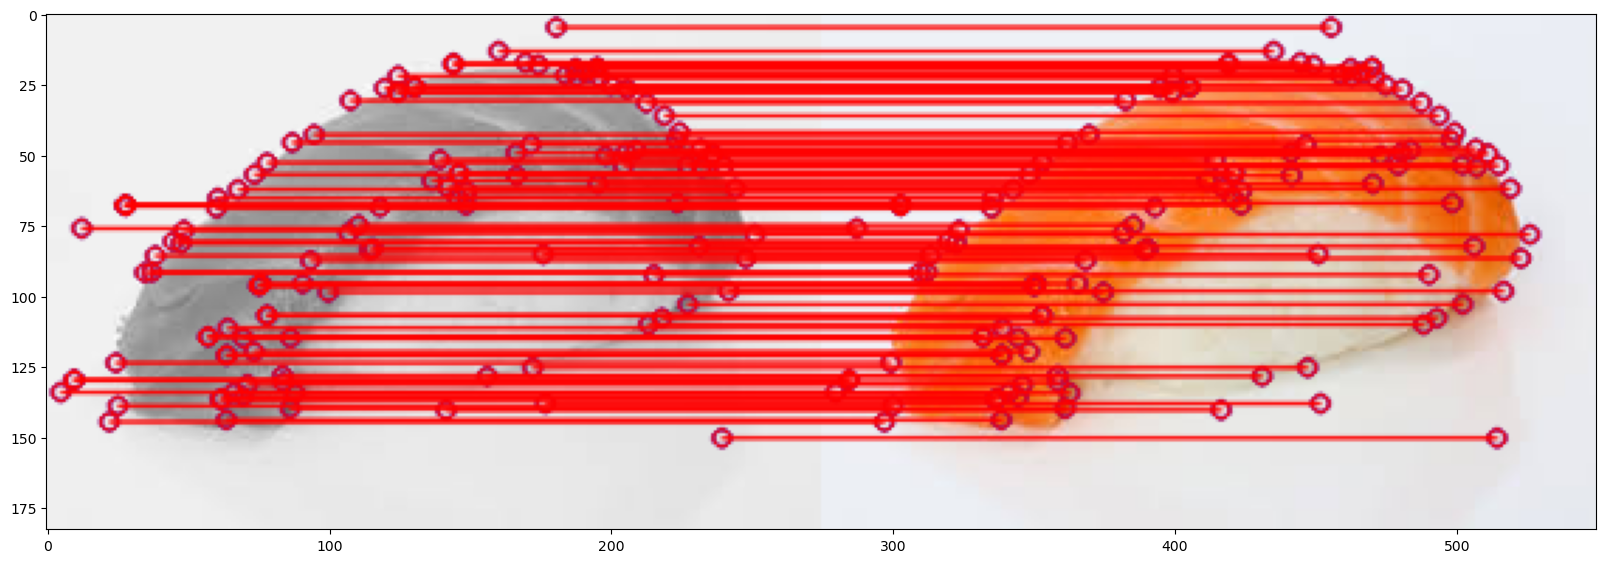

In [11]:
# Visualize matching
result = cv2.drawMatchesKnn(
    target_img, #target image yang mau dicocokin
    target_kp, #keypoints target image
    best_match_data['image_data'], #image yang match
    best_match_data['keypoints'], #keypoints image yang match
    best_match_data['match'], # points yang match
    None, 
    matchesMask=best_match_data['matches_mask'],
    matchColor=[255, 0, 0], # Color for matching points (red)
    singlePointColor= [0, 0, 255], # Color for unmatched keypoints blue
)

plt.figure(figsize=(20,10))
plt.imshow(result)
plt.show() # gataw 

# kuis gada teori, tips -> pahami codingan dari 3 sampe 6, 1-2 intro doang, pahamin dan hapalin pure template semua
